In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    '../../data/processed/final_dataset.csv'
)

df.head()

,country,country_code,year,co2_per_capita,gdp,population,renewable_energy,energy_consumption
0,Afghanistan,AFG,1949,0.001992,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1950,0.010837,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1951,0.011625,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1952,0.011468,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1953,0.013123,NaN,NaN,NaN,NaN


In [3]:
print(df.shape)
print(df.columns)
print(df.isna().sum())
print(df.info())

(26509, 8)
Index(['country', 'country_code', 'year', 'co2_per_capita', 'gdp',
       'population', 'renewable_energy', 'energy_consumption'],
      dtype='object')
country                   0
country_code           1146
year                      0
co2_per_capita            0
gdp                   16834
population            15337
renewable_energy      20908
energy_consumption    16094
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26509 entries, 0 to 26508
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             26509 non-null  object 
 1   country_code        25363 non-null  object 
 2   year                26509 non-null  int64  
 3   co2_per_capita      26509 non-null  float64
 4   gdp                 9675 non-null   float64
 5   population          11172 non-null  float64
 6   renewable_energy    5601 non-null   float64
 7   energy_consumption  10415 non-null  float64
d

KPI Features ⭐

In [4]:
#Energy Efficiency
df['energy_efficiency'] = (
    df['gdp'] / df['energy_consumption']
)

In [5]:
#Carbon Intensity
df['carbon_intensity'] = (
    df['co2_per_capita'] / df['gdp']
)

1. Which countries have highest CO₂ emissions?
2. Does renewable energy reduce emissions?
3. Relationship between GDP and CO₂?
4. Which countries improved sustainability?
5. Energy consumption trends over time?

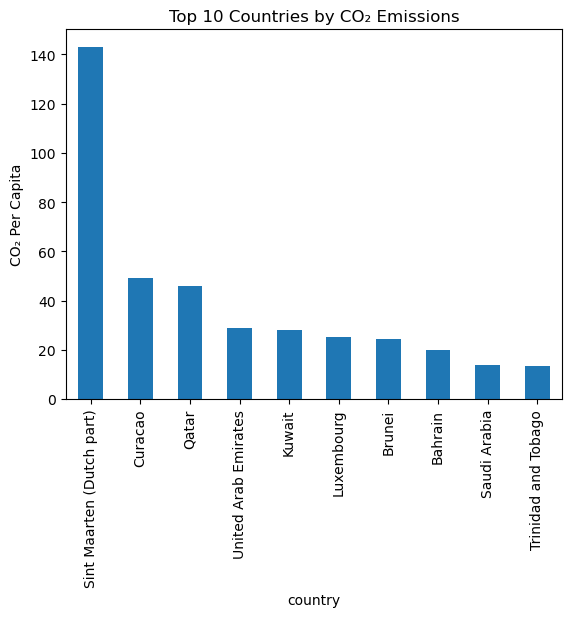

In [8]:
# Easy comparison between countries.
top10 = (
    df.groupby('country')['co2_per_capita']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10.plot(kind='bar')

plt.title('Top 10 Countries by CO₂ Emissions')
plt.ylabel('CO₂ Per Capita')

plt.show()

Countries with strong dependence on oil production and fossil fuel-based energy systems tend to exhibit higher CO₂ emissions per capita, emphasizing the need for sustainability-focused energy transition policies.

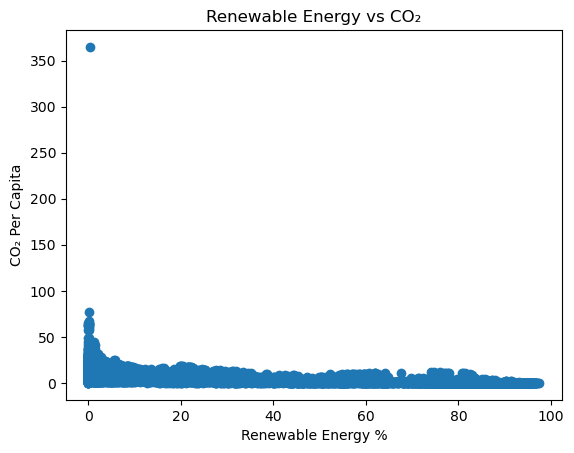

In [9]:
# Analyze sustainability impact.
plt.scatter(
    df['renewable_energy'],
    df['co2_per_capita']
)

plt.xlabel('Renewable Energy %')
plt.ylabel('CO₂ Per Capita')

plt.title('Renewable Energy vs CO₂')

plt.show()

The scatter plot indicates an inverse relationship between renewable energy usage and CO₂ emissions per capita. Countries with higher renewable energy adoption generally tend to have lower carbon emissions, suggesting that renewable energy can contribute to reducing environmental impact and improving sustainability.

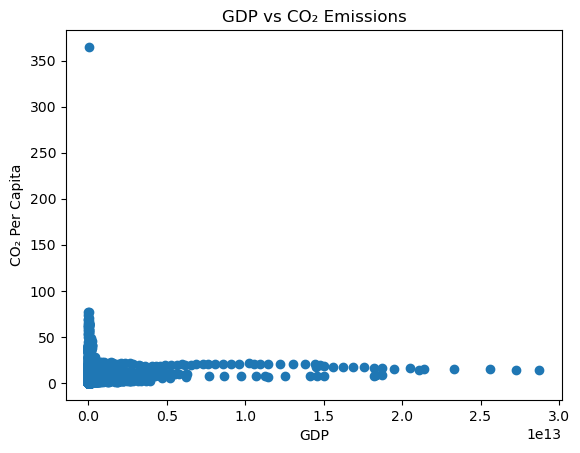

In [10]:
#Understand whether economic growth increases emissions.


plt.scatter(
    df['gdp'],
    df['co2_per_capita']
)

plt.xlabel('GDP')
plt.ylabel('CO₂ Per Capita')

plt.title('GDP vs CO₂ Emissions')

plt.show()

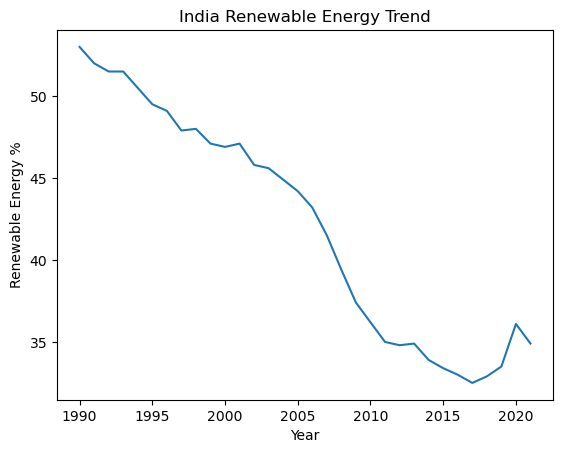

In [11]:
# Find countries reducing emissions or increasing renewable usage.

india = df[df['country'] == 'India']

plt.plot(
    india['year'],
    india['renewable_energy']
)

plt.title('India Renewable Energy Trend')

plt.xlabel('Year')
plt.ylabel('Renewable Energy %')

plt.show()

The analysis shows a positive relationship between GDP and CO₂ emissions, indicating that economically developed countries generally produce higher carbon emissions due to increased industrialization, energy consumption, and economic activities. However, some high-GDP countries maintain relatively lower emissions, suggesting the impact of cleaner energy policies and sustainable technologies.

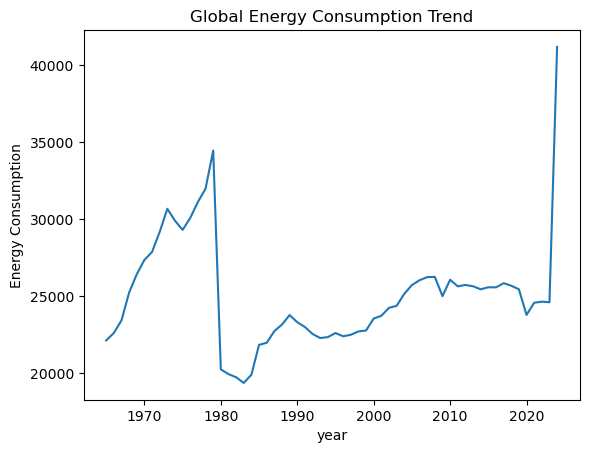

In [12]:
# Study long-term energy usage patterns.


energy_trend = (
    df.groupby('year')['energy_consumption']
    .mean()
)

energy_trend.plot()

plt.title('Global Energy Consumption Trend')

plt.ylabel('Energy Consumption')

plt.show()

The global energy consumption trend shows a long-term increase in energy usage over the years, reflecting growing industrialization, population growth, and economic development. Temporary declines and fluctuations may indicate economic slowdowns, energy crises, or global disruptions, while the sharp recent increase highlights rising global energy demand and expanding economic activities.

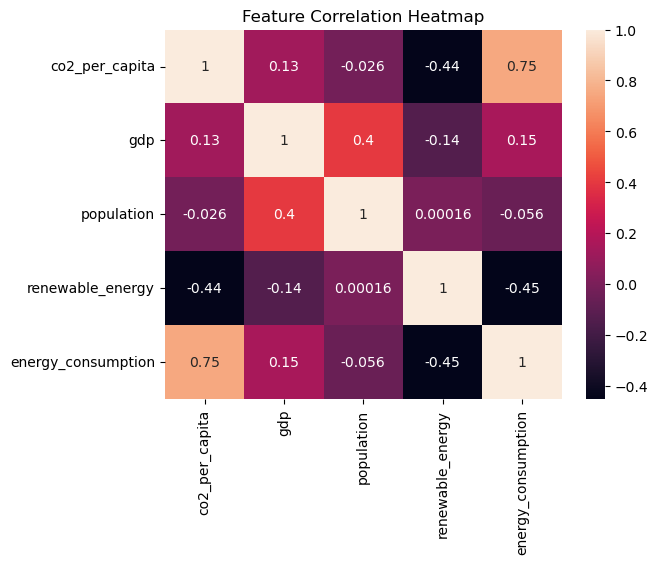

In [15]:
# Find strongest relationships between variables.





corr = df[
    [
        'co2_per_capita',
        'gdp',
        'population',
        'renewable_energy',
        'energy_consumption'
    ]
].corr()

sns.heatmap(corr, annot=True)

plt.title('Feature Correlation Heatmap')

plt.show()

The correlation analysis reveals that energy consumption has a strong positive relationship with CO₂ emissions, indicating that higher energy usage significantly contributes to increased carbon emissions. Renewable energy shows a negative correlation with both CO₂ emissions and energy consumption, suggesting that greater adoption of renewable energy may help reduce environmental impact. GDP has a moderate positive relationship with population and a weak positive relationship with CO₂ emissions, reflecting the influence of economic growth on energy demand and emissions.

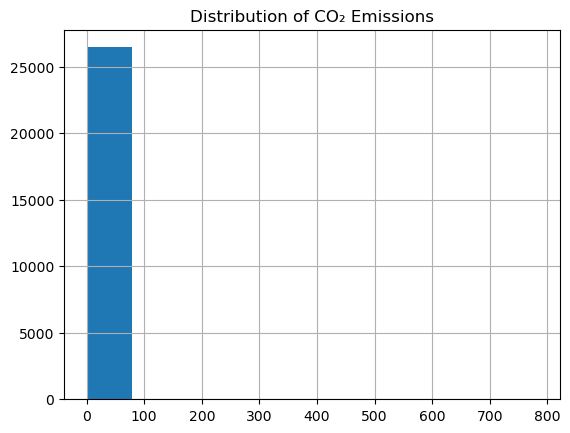

In [16]:
# Understand data distribution.

df['co2_per_capita'].hist()

plt.title('Distribution of CO₂ Emissions')

plt.show()

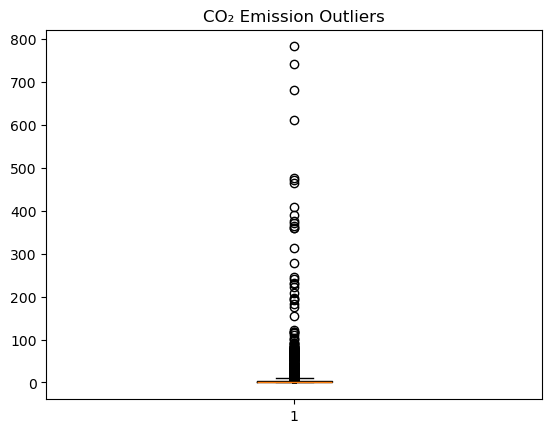

In [17]:
# Detect outliers.



plt.boxplot(df['co2_per_capita'])

plt.title('CO₂ Emission Outliers')

plt.show()

The distribution analysis shows that most countries have relatively low to moderate CO₂ emissions per capita, while a small number of countries exhibit extremely high emission values. The boxplot confirms the presence of significant outliers, indicating that certain economies or regions contribute disproportionately to global carbon emissions. These outliers are likely associated with highly industrialized or fossil fuel-dependent countries and may require focused sustainability and emission reduction policies.

utliers in CO₂ emissions data, but since they represented genuine high-emission economies rather than data errors,